In [209]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [210]:
def f(x):
    return 3*x**2 - 4*x + 5

In [211]:
f(3.0)

20.0

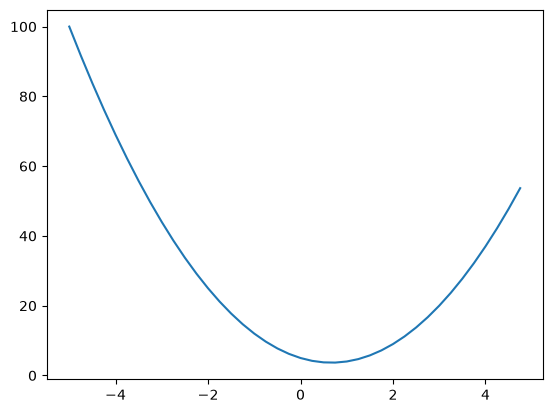

In [212]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys
plt.plot(xs, ys)

In [213]:
# --- Numerical derivative ---
# The derivative tells us: if I nudge x by a tiny amount h,
# how much does f(x) change, and in which direction?
#
# Definition:  f'(x) = lim (h -> 0) of  (f(x + h) - f(x)) / h
#
#   f(x + h) - f(x)   -> how much the output changed ("rise")
#   / h               -> divided by how much we nudged the input ("run")
#   = slope of f at x -> the sensitivity of the output to the input
#
# Here f(x) = 3x^2 - 4x + 5, so analytically f'(x) = 6x - 4
# At x = 3.0: f'(3) = 6*3 - 4 = 14, and the numerical estimate should be ~14.
#
# Sign of the derivative:
#   positive -> increasing x increases f
#   negative -> increasing x decreases f
#   zero     -> f is flat here (e.g. the minimum of the parabola, at x = 2/3)
#
# Note: h must be small, but not TOO small. With a very tiny h, floating-point
# rounding errors dominate and the result becomes inaccurate.
#
# Why this matters: training a neural network means finding out how the loss
# changes when each weight is nudged, which is exactly this idea. Backprop
# is just an efficient way to compute these derivatives for every weight at once.

h = 0.00000001
x = 3.0
(f(x + h) - f(x)) / h

14.00000009255109

In [214]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c 
print(d)

4.0


In [215]:
h = 0.000001

#inputs 
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 -d1)/h)

d1 4.0
d2 3.9999969999999996
slope -3.000000000419334


In [320]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(label={self.label}, data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)  #this permits additions with int, before both had do be Value isntants 
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():  
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):  # this is used so we can do 2 * a, before that we could only do a * 2
        return self * other

    def __truediv__(self, other):
        return self * other**(-1)

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad +=  (1- t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []          # the ordered list we're building
        visited = set()    # nodes we've already processed, so none is added twice

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:   # first, process everything that created v...
                    build_topo(child)
                topo.append(v)          # ...then add v itself, after all its children

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label= 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(label=L, data=-8.0)

In [291]:
a = Value(2.0)
a*3
a.exp()

b = Value(4.0)

a / b

a - b

Value(label=, data=-2.0)

In [243]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any  vlaue in the grpah, create a rectangular (;record') node for it
        dot.node(name = uid, label= "{%s | data %.4f | grad %.4f }" %(n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this values is a result of some operation, create an 'op; node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node for n2 
        dot.edge(str(id(n1)), str(id(n2)) +n2._op)
    return dot

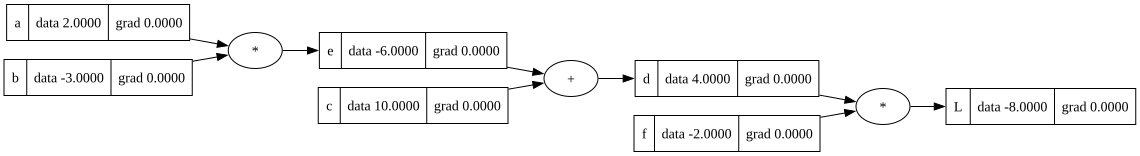

In [218]:
draw_dot(L)

   **dL/dd**, where L = d · f

   (L(d+h) - L(d)) / h
   = ((d+h)·f - d·f) / h
   = (d·f + f·h - d·f) / h
   = f·h / h
   = f

In [219]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = -2.0 * 3.0
b.grad = -2.0 * 2.0

In [220]:
dd / dc  

d = c + e

f(x+h) - f(x) / h

(c + h + e) - (c + e)/h

1.0 


NameError: name 'dd' is not defined

In [221]:
def lol ():

    h = 0.001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label= 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label= 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data + h

    print((L2 - L1)/h)

lol()

1.000000000000334


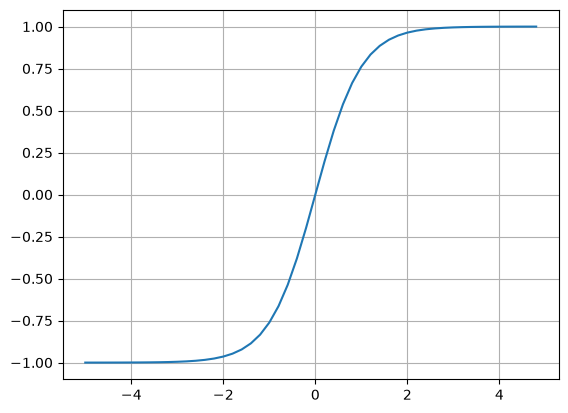

In [222]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

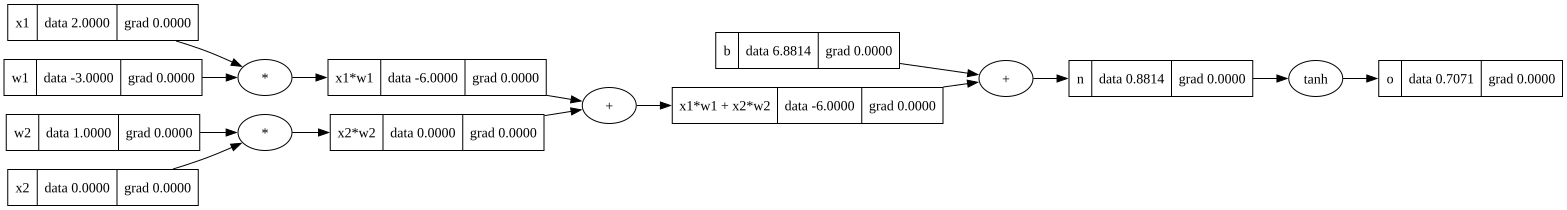

In [316]:
# inputs x1, x2

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron

b = Value(6.8813735870195432, label = 'b')

# x1 * w1 + x2 * w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

draw_dot(o)

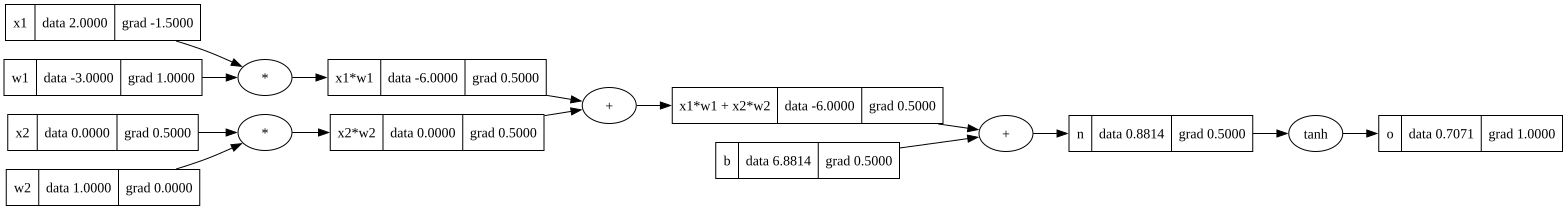

In [300]:
draw_dot(o)

In [295]:
o.grad = 1.0

In [296]:
o._backward()

In [297]:
n._backward()

In [ ]:
b._backward() #nothing happens cause b is a leaf

AttributeError: 'Value' object has no attribute '_backward'

In [298]:
x1w1x2w2._backward()

In [299]:
x1w1._backward()
x2w2._backward()

## The `_backward` function

`_backward` automates the manual backpropagation we did by hand.
Each operation (`+`, `*`, `tanh`) stores its own local derivative rule,
and applies the chain rule: `child.grad += local_derivative * out.grad`.

This gives **exact** gradients using calculus, unlike the numerical
method (nudging by h), which only approximates them and is used to
**check** that our `_backward` rules are correct.

### Order matters: start from the end

Backprop must start from the output (`L.grad = 1`) and go backward,
because each node's `_backward` needs its output's gradient to already
be final.

**Chain:** `1 → 2 → 3 → 4 → 5` (5 is the output)
To find `2.grad`, we first need `3.grad`, which needs `4.grad`,
which needs `5.grad`. Order: 5 → 4 → 3 → 2 → 1.

**Rule:** a node's gradient needs the gradients of every node that
depends on it (everything after it on its paths to the output).
Nodes on separate branches are not needed.

**Branching:** if node 2 feeds into both 3 and 4, and both lead to 5:

```
     ┌→ 3 ──┐
1 → 2       5
     └→ 4 ──┘
```

`2.grad` needs both `3.grad` and `4.grad`, and its gradient is the
**sum** of the contributions from both paths. This is why `_backward`
uses `+=` instead of `=`.

A **topological sort** puts the nodes in an order where every node comes
after its children; walking it in reverse guarantees each node is
processed only after everything that depends on it.

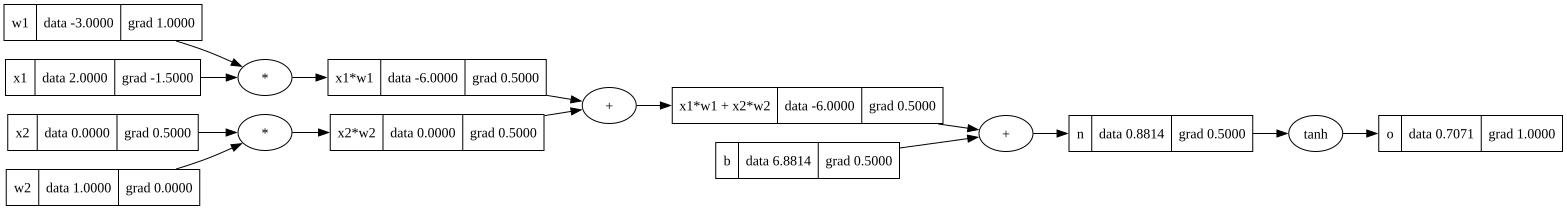

In [236]:
draw_dot(o)

In [233]:
# --- Manual backprop through the neuron ---
# Forward pass: n = x1*w1 + x2*w2 + b,  o = tanh(n)

# o is the output, so we start there: do/do = 1
o.grad = 1.0

# o = tanh(n)  →  local derivative do/dn = 1 - tanh(n)**2 = 1 - o**2
# (from calculus, or the "Hyperbolic functions" page on Wikipedia)
# o ≈ 0.7071, so 1 - 0.7071**2 = 0.5
# chain rule: n.grad = (1 - o**2) * o.grad = 0.5 * 1
n.grad = 0.5

# n = x1w1x2w2 + b  →  '+' passes the gradient through unchanged (local derivative = 1)
x1w1x2w2.grad = 0.5
b.grad = 0.5

# x1w1x2w2 = x1w1 + x2w2  →  '+' again, so both terms get 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [234]:
# '*' rule: each input's gradient = (the other input) * (output's gradient)

# x2w2 = x2 * w2
x2.grad = w2.data * x2w2.grad   # 1.0 * 0.5 = 0.5
w2.grad = x2.data * x2w2.grad   # 0.0 * 0.5 = 0.0  → x2 = 0, so w2 has no effect on o

# x1w1 = x1 * w1
x1.grad = w1.data * x1w1.grad   # -3.0 * 0.5 = -1.5
w1.grad = x1.data * x1w1.grad   #  2.0 * 0.5 =  1.0

In [235]:
# Check the local derivative of tanh at our output value: should be ~0.5
1 - o.data**2

0.4999999999999999

In [ ]:
# o = tanh(n)
# do/dn = 1 - o**2  we can find the derrivative function by calculus OR through wikipedia at Hyperobolic Functions it is 1 - tanh^2
# so do/dn result is the grad of n

# a plus sign is just a distributo of gradient so
# grad of b is 0.5
#grad of x1*w1 = x2*w2 is also 0.5

In [237]:
# --- Topological sort ---
# Builds a list of all nodes where every node appears AFTER its children
# (the values that were used to create it). Reversing this list gives
# the correct order for backprop: output first, inputs last.

topo = []          # the ordered list we're building
visited = set()    # nodes we've already processed, so none is added twice

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:   # first, process everything that created v...
            build_topo(child)
        topo.append(v)          # ...then add v itself, after all its children

build_topo(o)
topo   # inputs come first, the output o comes last

[Value(label=b, data=6.881373587019543),
 Value(label=x1, data=2.0),
 Value(label=w1, data=-3.0),
 Value(label=x1*w1, data=-6.0),
 Value(label=x2, data=0.0),
 Value(label=w2, data=1.0),
 Value(label=x2*w2, data=0.0),
 Value(label=x1*w1 + x2*w2, data=-6.0),
 Value(label=n, data=0.8813735870195432),
 Value(label=o, data=0.7071067811865476)]

In [245]:
o.grad = 1.0

topo = []          # the ordered list we're building
visited = set()    # nodes we've already processed, so none is added twice

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:   # first, process everything that created v...
            build_topo(child)
        topo.append(v)          # ...then add v itself, after all its children

build_topo(o)

for node in reversed(topo):
    node._backward()

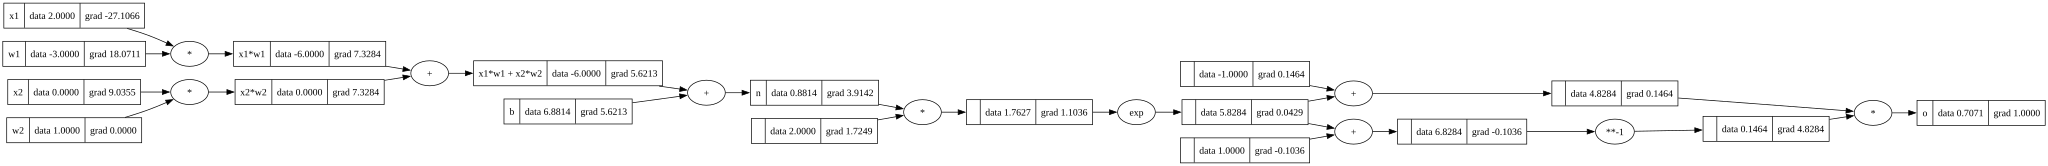

In [314]:
draw_dot(o)

In [302]:
o.backward()

o.data: 0.7071067811865477
e.grad: 0.04289321881345247
n.grad: 0.5


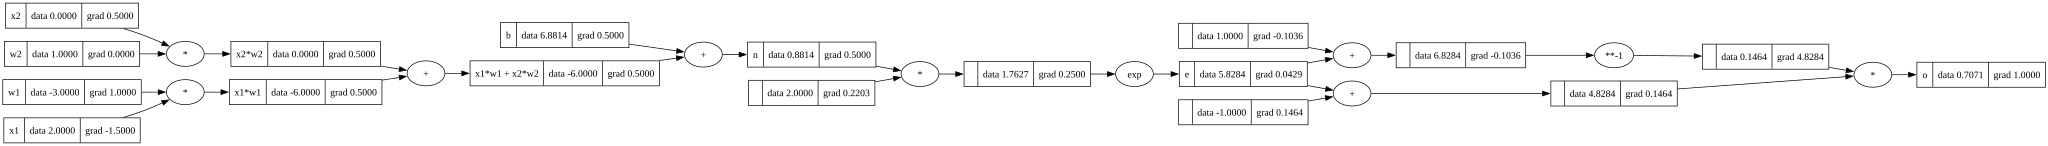

In [ ]:
# inputs x1, x2

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron

b = Value(6.8813735870195432, label = 'b')

# x1 * w1 + x2 * w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# same as o = n.tanh() just written differnently
e = (2*n).exp() 
o = (e - 1) / (e + 1)
#
o.label = 'o'
o.backward()
e.label = 'e'
draw_dot(o)